<a href="https://colab.research.google.com/github/zesi3012/KNN/blob/main/JURNAL_NLP_UAS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PENELITIAN: Identifikasi Faktor Dominan Pembentuk Sentimen Negatif
Masyarakat terhadap Pelemahan Rupiah Menggunakan NLP dan Topic Modeling

1. INSTALL REQUIRED LIBRARIES

In [ ]:
import warnings
import os

# Suppress all warnings
warnings.filterwarnings('ignore')
os.environ['PYTHONWARNINGS'] = 'ignore'

# Untuk jupyter kernel jika masih ada
import sys
if not sys.warnoptions:
    warnings.simplefilter("ignore")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
import subprocess
import sys

def install_packages():
    packages = [
        'pandas',
        'numpy',
        'matplotlib',
        'seaborn',
        'scikit-learn',
        'nltk',
        'textblob',
        'gensim',
        'pyLDAvis',
        'wordcloud',
        'Sastrawi', # Changed to 'Sastrawi' (capital S)
        'datasets',
        'plotly',
        'kaleido'
    ]

    for package in packages:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package, "-q"])

install_packages() # Calling the function to install packages

2. IMPORT LIBRARIES

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# NLP & Text Processing
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from textblob import TextBlob

# Explicitly install Sastrawi to ensure it's available
!pip install Sastrawi -q
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory # Corrected import

# Topic Modeling
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from gensim import corpora, models as gensim_models_module # Aliased gensim.models to avoid conflict
from gensim.models import CoherenceModel
import pyLDAvis # Explicitly import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

# Visualization
from wordcloud import WordCloud
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

# Install kaleido for plotly image export
!pip install kaleido -q

# Download required NLTK data
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)

print("✓ Semua library berhasil dimuat")

✓ Semua library berhasil dimuat


LOAD DATASET DARI HUGGING FACE

In [ ]:
import pandas as pd
from datasets import load_dataset

print("\n" + "="*80)
print("TAHAP 1: LOADING DATA DARI HUGGING FACE")
print("="*80)

try:
    # Load dataset dari Hugging Face
    dataset = load_dataset('persephone3012/sentimen_fluktuasi_rupiah')

    # Konversi ke pandas DataFrame
    df = pd.DataFrame(dataset['train'])

    print(f"✓ Dataset berhasil dimuat dari Hugging Face")

except Exception as e:
    print(f"Error: {e}")
    # Fallback: load dari URL langsung
    url = "https://huggingface.co/datasets/persephone3012/sentimen_fluktuasi_rupiah/raw/main/dataset_sentimen_rupiah_5000.csv"
    df = pd.read_csv(url)
    print(f"✓ Dataset berhasil dimuat dari URL")

print(f"\nInfo Dataset:")
print(f"  - Total baris: {len(df)}")
print(f"  - Kolom: {list(df.columns)}")

print(f"\nSample data:")
print(df.head(10))

print(f"\nInfo tipe data:")
print(df.dtypes)

print(f"\nDeskripsi statistik:")
print(df.describe())


TAHAP 1: LOADING DATA DARI HUGGING FACE
✓ Dataset berhasil dimuat dari Hugging Face

Info Dataset:
  - Total baris: 5000
  - Kolom: ['id', 'tanggal', 'platform', 'teks', 'sentimen']

Sample data:
   id     tanggal platform                                               teks  \
0   1  2026-12-09        X             Rupiah melemah tajam terhadap dolar AS   
1   2  2026-12-04        X  Kebijakan terbaru dinilai mampu menstabilkan r...   
2   3  2026-02-19        X          Tekanan global menyebabkan rupiah melemah   
3   4  2026-02-07        X             Rupiah melemah tajam terhadap dolar AS   
4   5  2026-01-18        X        Ekonomi domestik mendukung penguatan rupiah   
5   6  2026-07-08        X        Ekonomi domestik mendukung penguatan rupiah   
6   7  2026-01-25        X            Nilai tukar rupiah terus turun hari ini   
7   8  2026-06-09        X               Data kurs rupiah diperbarui sore ini   
8   9  2026-02-03        X   Investor optimis nilai tukar rupiah akan memb

4. EXPLORATORY DATA ANALYSIS (EDA)

Cek missing values

In [ ]:
print(f"\nMissing Values:")
print(df.isnull().sum())


Missing Values:
id          0
tanggal     0
platform    0
teks        0
sentimen    0
dtype: int64


Distribusi Sentimen

In [ ]:
print(f"\nDistribusi Sentimen:")
sentimen_counts = df['sentimen'].value_counts()
print(sentimen_counts)
sentimen_percentage = (sentimen_counts / len(df) * 100).round(2)
print(f"\nPersentase Sentimen:")
print(sentimen_percentage)


Distribusi Sentimen:
sentimen
negatif    2039
netral     1508
positif    1453
Name: count, dtype: int64

Persentase Sentimen:
sentimen
negatif    40.78
netral     30.16
positif    29.06
Name: count, dtype: float64


Visualisasi Distribusi Sentimen

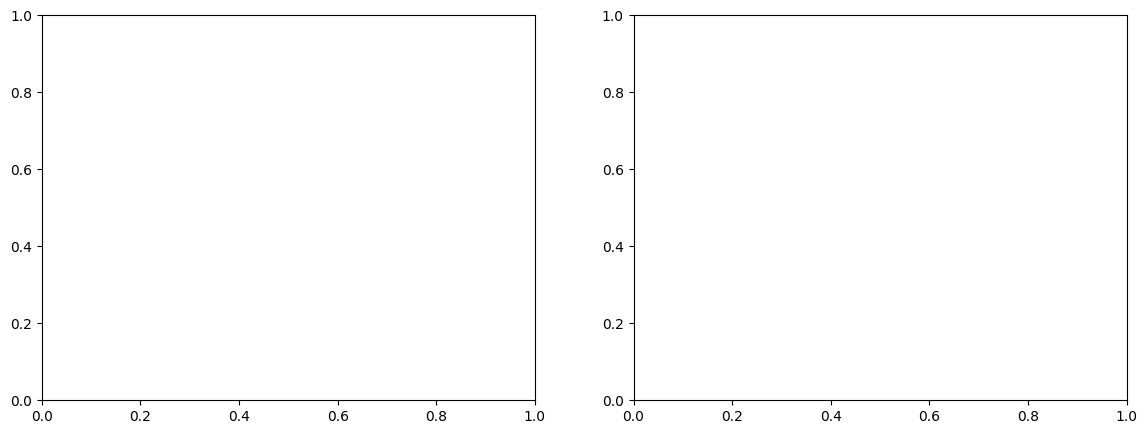

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

Bar plot

In [ ]:
sentimen_counts.plot(kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71', '#3498db'])
axes[0].set_title('Distribusi Sentimen (Count)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Sentimen')
axes[0].set_ylabel('Jumlah')
axes[0].tick_params(axis='x', rotation=0)

Pie chart

In [ ]:
colors = ['#e74c3c', '#2ecc71', '#3498db']
axes[1].pie(sentimen_counts, labels=sentimen_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90)
axes[1].set_title('Proporsi Sentimen', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('01_distribusi_sentimen.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Visualisasi distribusi sentimen tersimpan")

<Figure size 640x480 with 0 Axes>


✓ Visualisasi distribusi sentimen tersimpan


Statistik teks

In [ ]:
df['text_length'] = df['teks'].apply(len)
df['word_count'] = df['teks'].apply(lambda x: len(x.split()))

print(f"\nStatistik Panjang Teks:")
print(df['text_length'].describe())

print(f"\nStatistik Jumlah Kata:")
print(df['word_count'].describe())


Statistik Panjang Teks:
count    5000.000000
mean       42.645800
std         4.519649
min        36.000000
25%        39.000000
50%        42.000000
75%        47.000000
max        51.000000
Name: text_length, dtype: float64

Statistik Jumlah Kata:
count    5000.000000
mean        5.946200
std         0.753538
min         5.000000
25%         5.000000
50%         6.000000
75%         7.000000
max         7.000000
Name: word_count, dtype: float64


Visualisasi panjang teks berdasarkan sentimen

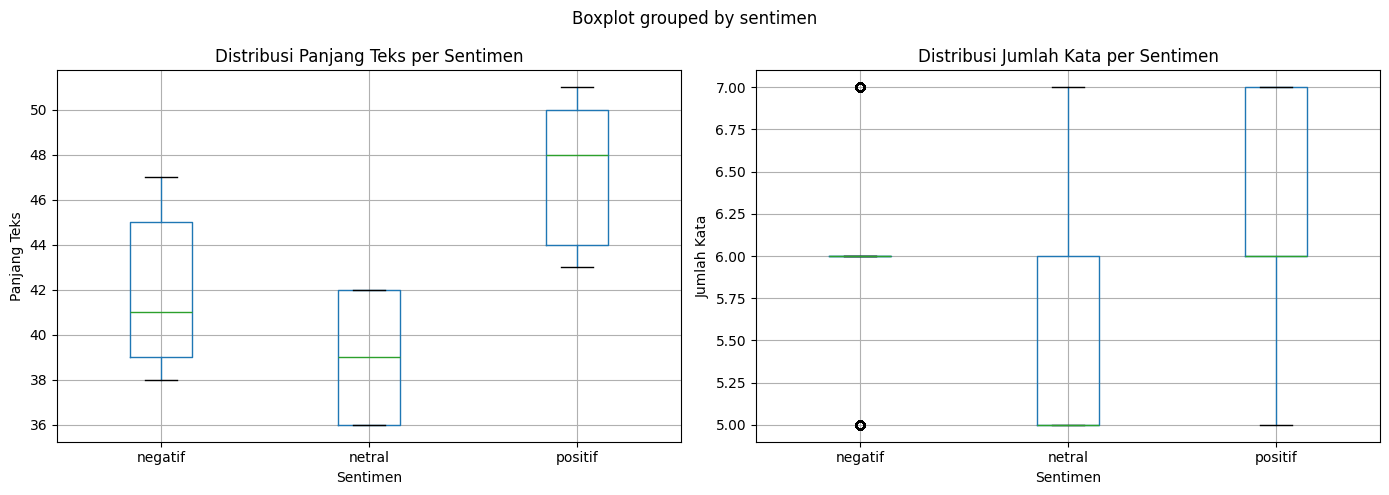

✓ Visualisasi statistik teks tersimpan


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df.boxplot(column='text_length', by='sentimen', ax=axes[0])
axes[0].set_title('Distribusi Panjang Teks per Sentimen')
axes[0].set_xlabel('Sentimen')
axes[0].set_ylabel('Panjang Teks')
plt.sca(axes[0])
plt.xticks(rotation=0)

df.boxplot(column='word_count', by='sentimen', ax=axes[1])
axes[1].set_title('Distribusi Jumlah Kata per Sentimen')
axes[1].set_xlabel('Sentimen')
axes[1].set_ylabel('Jumlah Kata')
plt.sca(axes[1])
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig('02_statistik_teks.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualisasi statistik teks tersimpan")

Platform distribution

In [ ]:
print(f"\nDistribusi Platform:")
print(df['platform'].value_counts())


Distribusi Platform:
platform
X    5000
Name: count, dtype: int64


Temporal analysis

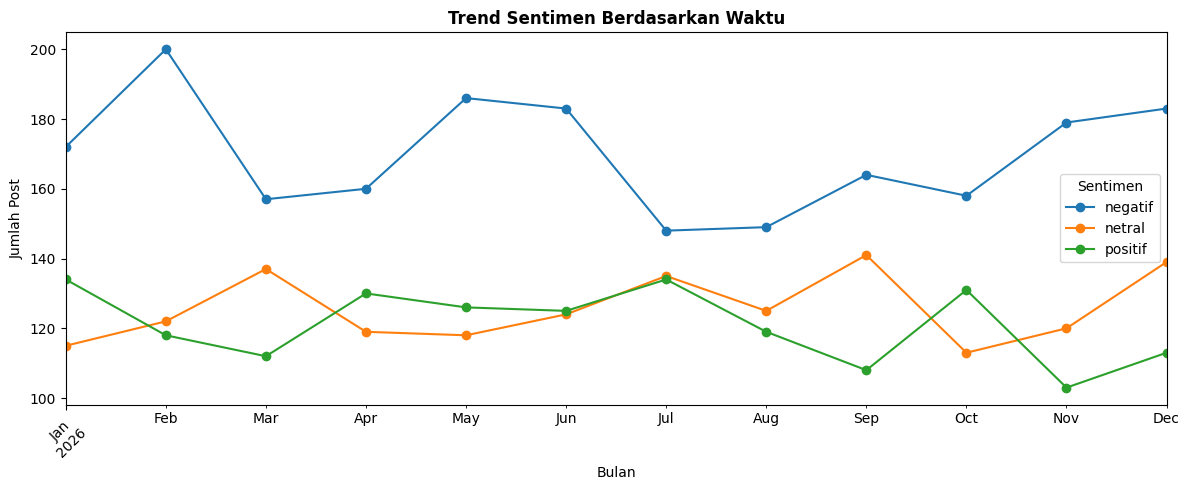

✓ Analisis temporal tersimpan


In [ ]:
df['tanggal'] = pd.to_datetime(df['tanggal'])
df['bulan'] = df['tanggal'].dt.to_period('M')

fig, ax = plt.subplots(figsize=(12, 5))
df.groupby(['bulan', 'sentimen']).size().unstack().plot(ax=ax, marker='o')
ax.set_title('Trend Sentimen Berdasarkan Waktu', fontsize=12, fontweight='bold')
ax.set_xlabel('Bulan')
ax.set_ylabel('Jumlah Post')
ax.legend(title='Sentimen')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('03_temporal_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Analisis temporal tersimpan")


5. TEXT PREPROCESSING

Inisialisasi tools

In [ ]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory # Ensure StemmerFactory is imported
factory = StemmerFactory()
stemmer_indo = factory.create_stemmer()
stop_words_indo = set(stopwords.words('indonesian'))

def preprocess_text(text):
    """
    Fungsi untuk preprocessing teks
    """
    # 1. Convert to lowercase
    text = str(text).lower()

    # 2. Remove special characters and numbers
    import re
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # 3. Remove extra whitespace
    text = ' '.join(text.split())

    # 4. Tokenization
    tokens = text.split()

    # 5. Remove stopwords
    tokens = [word for word in tokens if word not in stop_words_indo and len(word) > 2]

    # 6. Stemming
    tokens = [stemmer_indo.stem(word) for word in tokens]

    return ' '.join(tokens)

print("Preprocessing teks... (ini membutuhkan waktu)")
# Ensure tqdm is imported for progress_apply if not already
try:
    from tqdm.auto import tqdm
    tqdm.pandas()
except ImportError:
    pass

df['teks_cleaned'] = df['teks'].progress_apply(preprocess_text)

print("✓ Text preprocessing selesai")
print(f"\nContoh preprocessing:")
for i in range(3):
    print(f"\nOriginal: {df['teks'].iloc[i]}")
    print(f"Cleaned:  {df['teks_cleaned'].iloc[i]}")

Preprocessing teks... (ini membutuhkan waktu)


  0%|          | 0/5000 [00:00<?, ?it/s]

✓ Text preprocessing selesai

Contoh preprocessing:

Original: Rupiah melemah tajam terhadap dolar AS
Cleaned:  rupiah lemah tajam dolar

Original: Kebijakan terbaru dinilai mampu menstabilkan rupiah
Cleaned:  bijak baru nilai stabil rupiah

Original: Tekanan global menyebabkan rupiah melemah
Cleaned:  tekan global sebab rupiah lemah


6. SENTIMENT ANALYSIS MENDALAM

In [ ]:
# Analisis sentimen menggunakan TextBlob (untuk pemahaman polarity)
def analyze_sentiment_polarity(text):
    """
    Analisis sentiment polarity menggunakan TextBlob
    """
    blob = TextBlob(text)
    return blob.sentiment.polarity

print("Menganalisis sentiment polarity...")
df['polarity'] = df['teks'].progress_apply(analyze_sentiment_polarity)


Menganalisis sentiment polarity...


  0%|          | 0/5000 [00:00<?, ?it/s]

Kategorisasi polarity

In [ ]:
def categorize_polarity(polarity):
    if polarity > 0.1:
        return 'Positif'
    elif polarity < -0.1:
        return 'Negatif'
    else:
        return 'Netral'

df['polarity_category'] = df['polarity'].apply(categorize_polarity)

print("\nDistribusi Polarity Score:")
print(df['polarity'].describe())

print("\nDistribusi Polarity Category:")
print(df['polarity_category'].value_counts())



Distribusi Polarity Score:
count    5000.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: polarity, dtype: float64

Distribusi Polarity Category:
polarity_category
Netral    5000
Name: count, dtype: int64


Visualisasi Polarity

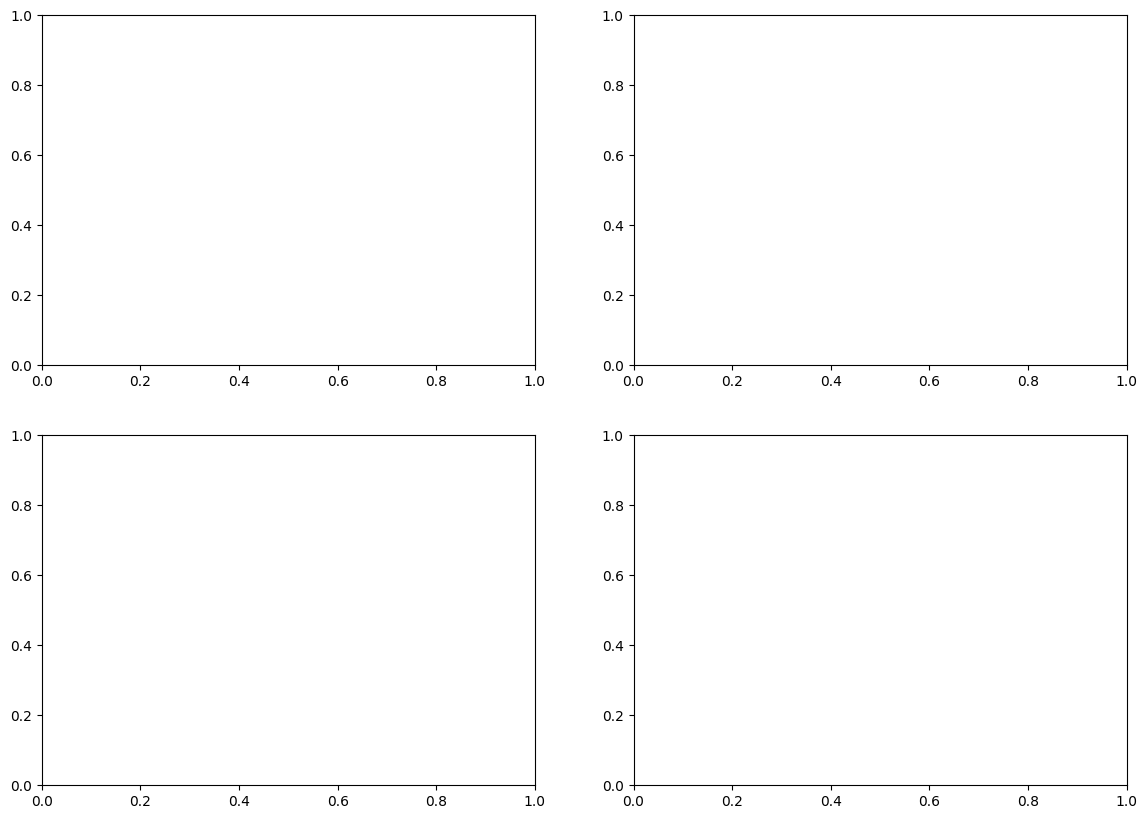

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

Histogram polarity

In [ ]:
axes[0, 0].hist(df['polarity'], bins=50, color='#3498db', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Distribusi Polarity Score', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Polarity Score')
axes[0, 0].set_ylabel('Frekuensi')
axes[0, 0].axvline(x=0, color='red', linestyle='--', linewidth=2)

Box plot polarity per sentimen

In [ ]:
df.boxplot(column='polarity', by='sentimen', ax=axes[0, 1])
axes[0, 1].set_title('Polarity Score per Sentimen')
axes[0, 1].set_xlabel('Sentimen')
axes[0, 1].set_ylabel('Polarity Score')
plt.sca(axes[0, 1])
plt.xticks(rotation=0)

(array([1, 2, 3]),
 [Text(1, 0, 'negatif'), Text(2, 0, 'netral'), Text(3, 0, 'positif')])

Scatter plot: word_count vs polarity

In [ ]:
scatter = axes[1, 0].scatter(df['word_count'], df['polarity'],
                             c=pd.Categorical(df['sentimen']).codes,
                             cmap='viridis', alpha=0.6, s=30)
axes[1, 0].set_title('Word Count vs Polarity Score')
axes[1, 0].set_xlabel('Word Count')
axes[1, 0].set_ylabel('Polarity Score')
plt.colorbar(scatter, ax=axes[1, 0])

Correlation heatmap

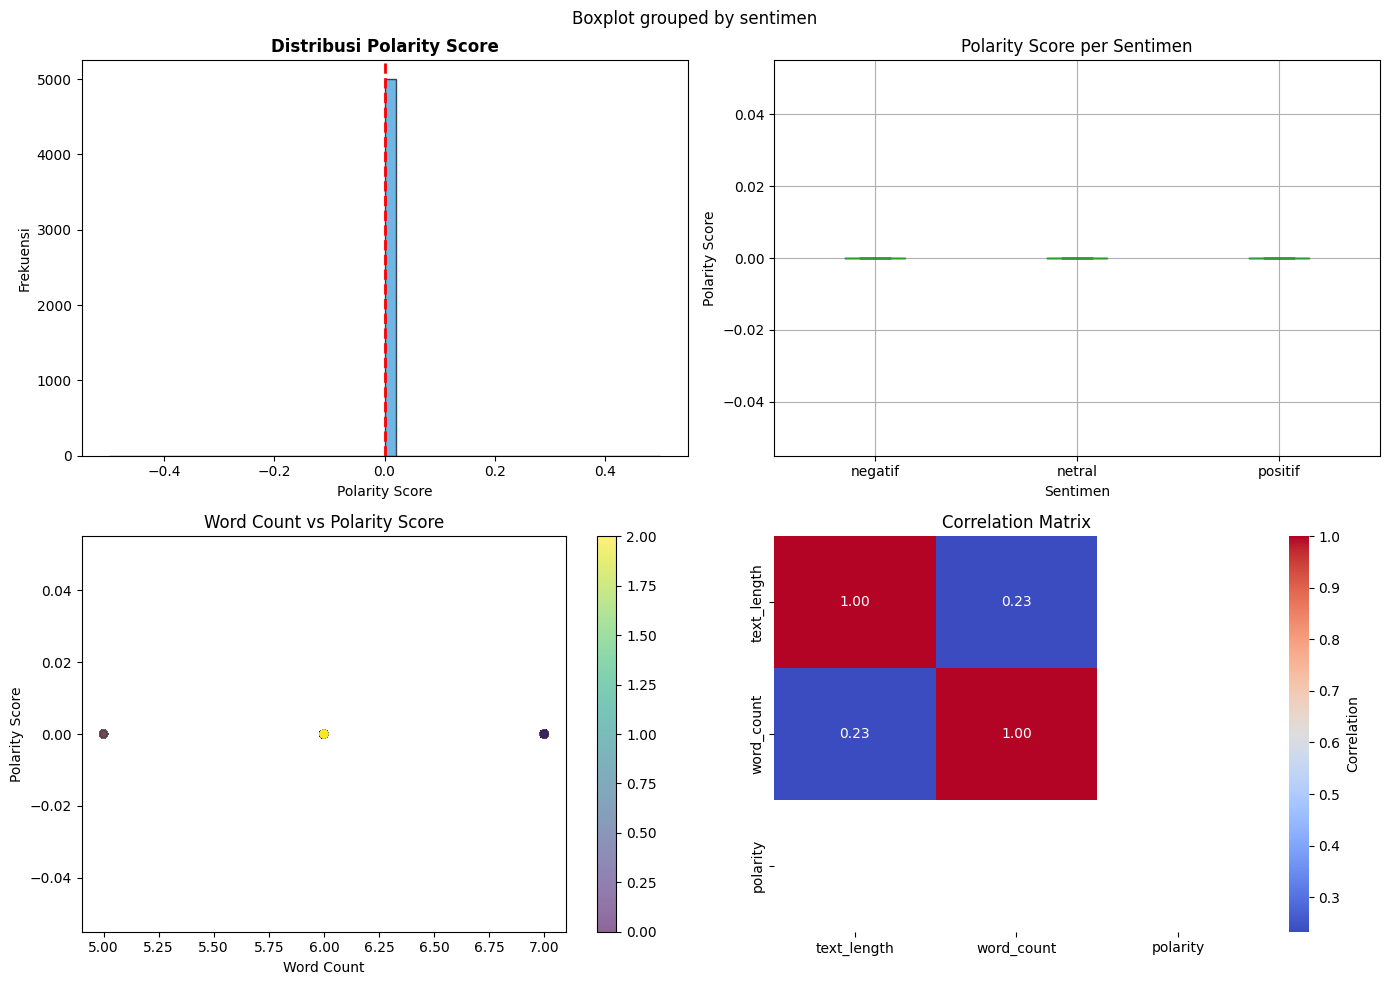

✓ Visualisasi sentiment analysis tersimpan


In [ ]:
correlation_data = df[['text_length', 'word_count', 'polarity']].corr()
sns.heatmap(correlation_data, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1, 1], cbar_kws={'label': 'Correlation'})
axes[1, 1].set_title('Correlation Matrix')

plt.tight_layout()
plt.savefig('04_sentiment_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualisasi sentiment analysis tersimpan")


7. FOCUS: ANALISIS SENTIMEN NEGATIF

Filter hanya sentimen negatif

In [ ]:
df_negative = df[df['sentimen'] == 'negatif'].copy()

print(f"\nTotal sentimen negatif: {len(df_negative)} ({len(df_negative)/len(df)*100:.2f}%)")
print(f"\nTop 20 sentimen negatif:")
print(df_negative['teks'].head(20))


Total sentimen negatif: 2039 (40.78%)

Top 20 sentimen negatif:
0              Rupiah melemah tajam terhadap dolar AS
2           Tekanan global menyebabkan rupiah melemah
3              Rupiah melemah tajam terhadap dolar AS
6             Nilai tukar rupiah terus turun hari ini
9             Nilai tukar rupiah terus turun hari ini
11    Investor khawatir karena rupiah semakin melemah
16            Nilai tukar rupiah terus turun hari ini
17            Nilai tukar rupiah terus turun hari ini
18          Tekanan global menyebabkan rupiah melemah
19      Pelemahan rupiah menekan daya beli masyarakat
20          Tekanan global menyebabkan rupiah melemah
21             Rupiah melemah tajam terhadap dolar AS
25            Nilai tukar rupiah terus turun hari ini
27          Tekanan global menyebabkan rupiah melemah
30    Investor khawatir karena rupiah semakin melemah
31          Tekanan global menyebabkan rupiah melemah
34             Rupiah melemah tajam terhadap dolar AS
38      Pelemahan

Analisis karakteristik sentimen negatif

In [ ]:
print(f"\nKarakteristik Sentimen Negatif:")
print(f"  - Rata-rata panjang teks: {df_negative['text_length'].mean():.2f}")
print(f"  - Rata-rata jumlah kata: {df_negative['word_count'].mean():.2f}")
print(f"  - Rata-rata polarity: {df_negative['polarity'].mean():.4f}")


Karakteristik Sentimen Negatif:
  - Rata-rata panjang teks: 42.10
  - Rata-rata jumlah kata: 6.01
  - Rata-rata polarity: 0.0000


8. FEATURE EXTRACTION UNTUK TOPIC MODELING

TF-IDF untuk semua data

In [ ]:
print("Creating TF-IDF vectors...")
tfidf_vectorizer = TfidfVectorizer(
    max_features=100,
    min_df=2,
    max_df=0.8,
    ngram_range=(1, 2)
)
tfidf_matrix = tfidf_vectorizer.fit_transform(df['teks_cleaned'])

print(f"✓ TF-IDF matrix shape: {tfidf_matrix.shape}")

Creating TF-IDF vectors...
✓ TF-IDF matrix shape: (5000, 90)


TF-IDF untuk sentimen negatif saja

In [ ]:
print("Creating TF-IDF vectors untuk sentimen negatif...")
tfidf_vectorizer_neg = TfidfVectorizer(
    max_features=100,
    min_df=1,
    max_df=0.9,
    ngram_range=(1, 2)
)
tfidf_matrix_neg = tfidf_vectorizer_neg.fit_transform(df_negative['teks_cleaned'])

print(f"✓ TF-IDF matrix (negatif) shape: {tfidf_matrix_neg.shape}")

Creating TF-IDF vectors untuk sentimen negatif...
✓ TF-IDF matrix (negatif) shape: (2039, 30)


Top TF-IDF terms

In [ ]:
top_tfidf_terms = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf_vectorizer.get_feature_names_out()
).mean().nlargest(20)

print(f"\nTop 20 TF-IDF Terms (All Data):")
print(top_tfidf_terms)


Top 20 TF-IDF Terms (All Data):
lemah                0.082254
rupiah lemah         0.074846
nilai                0.069570
nilai tukar          0.062058
tukar                0.062058
tukar rupiah         0.062058
dolar                0.057763
kuat                 0.056564
investor             0.050347
pasar                0.047597
tekan                0.046176
investor khawatir    0.040960
khawatir             0.040960
khawatir rupiah      0.040960
rupiah turun         0.040259
turun                0.040259
stabil               0.040016
lemah tajam          0.037379
tajam                0.037379
tajam dolar          0.037379
dtype: float64


Top TF-IDF terms untuk negatif

In [ ]:
top_tfidf_terms_neg = pd.DataFrame(
    tfidf_matrix_neg.toarray(),
    columns=tfidf_vectorizer_neg.get_feature_names_out()
).mean().nlargest(20)

print(f"\nTop 20 TF-IDF Terms (Sentimen Negatif):")
print(top_tfidf_terms_neg)


Top 20 TF-IDF Terms (Sentimen Negatif):
lemah                0.158108
rupiah lemah         0.156274
tekan                0.106229
investor             0.100734
investor khawatir    0.100734
khawatir             0.100734
khawatir rupiah      0.100734
dolar                0.091558
lemah tajam          0.091558
tajam                0.091558
tajam dolar          0.091558
nilai                0.081890
nilai tukar          0.081890
rupiah turun         0.081890
tukar                0.081890
tukar rupiah         0.081890
turun                0.081890
global               0.077047
global sebab         0.077047
sebab                0.077047
dtype: float64


Visualisasi

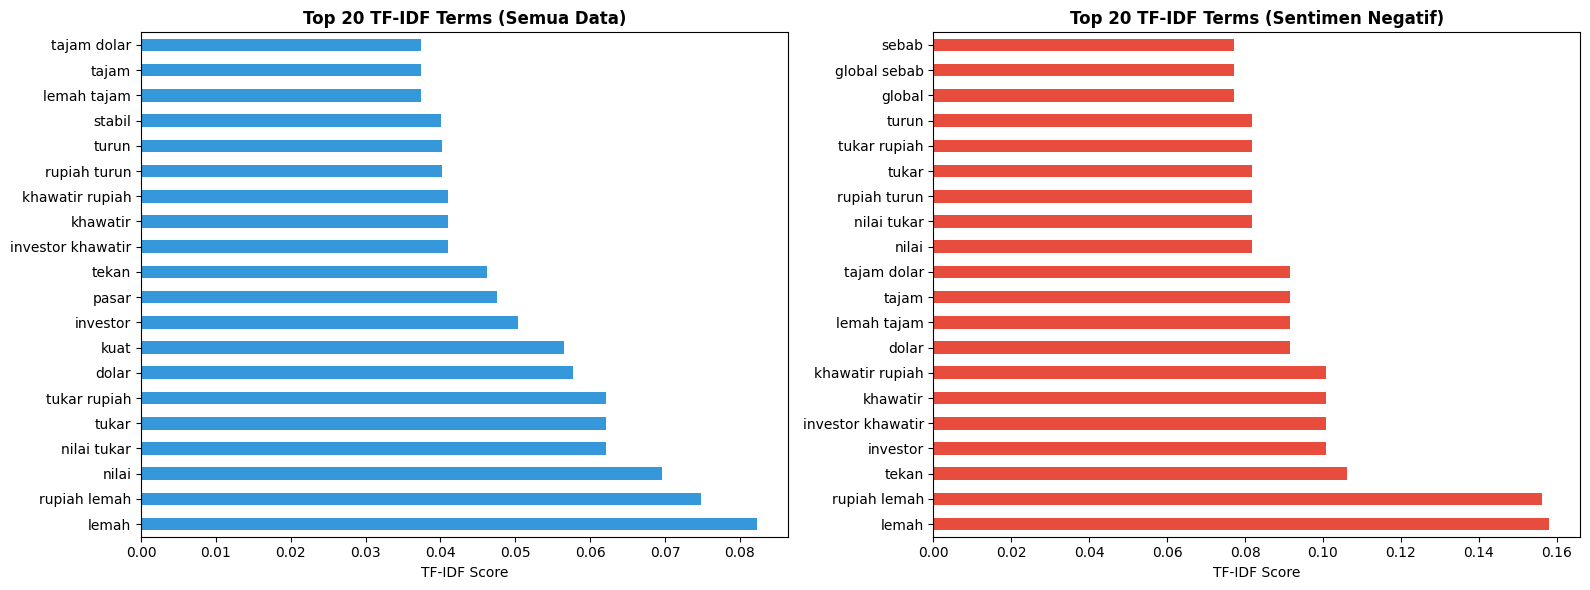

✓ Visualisasi TF-IDF tersimpan


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_tfidf_terms.plot(kind='barh', ax=axes[0], color='#3498db')
axes[0].set_title('Top 20 TF-IDF Terms (Semua Data)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('TF-IDF Score')

top_tfidf_terms_neg.plot(kind='barh', ax=axes[1], color='#e74c3c')
axes[1].set_title('Top 20 TF-IDF Terms (Sentimen Negatif)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('TF-IDF Score')

plt.tight_layout()
plt.savefig('05_tfidf_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualisasi TF-IDF tersimpan")

9. WORD FREQUENCY ANALYSIS


Top 30 Words (Semua Data):
  rupiah: 5000
  lemah: 1630
  nilai: 1279
  tukar: 994
  kuat: 898
  pasar: 896
  tekan: 792
  investor: 710
  dolar: 696
  stabil: 600
  baru: 592
  khawatir: 440
  turun: 409
  daya: 405
  beli: 405
  masyarakat: 405
  tajam: 398
  global: 387
  sebab: 387
  gerak: 317
  sesuai: 317
  kondisi: 317
  tutup: 315
  sentimen: 312
  positif: 312
  data: 307
  kurs: 307
  sore: 307
  bank: 302
  sentral: 302

Top 30 Words (Sentimen Negatif):
  rupiah: 2039
  lemah: 1630
  tekan: 792
  investor: 440
  khawatir: 440
  nilai: 409
  tukar: 409
  turun: 409
  daya: 405
  beli: 405
  masyarakat: 405
  tajam: 398
  dolar: 398
  global: 387
  sebab: 387


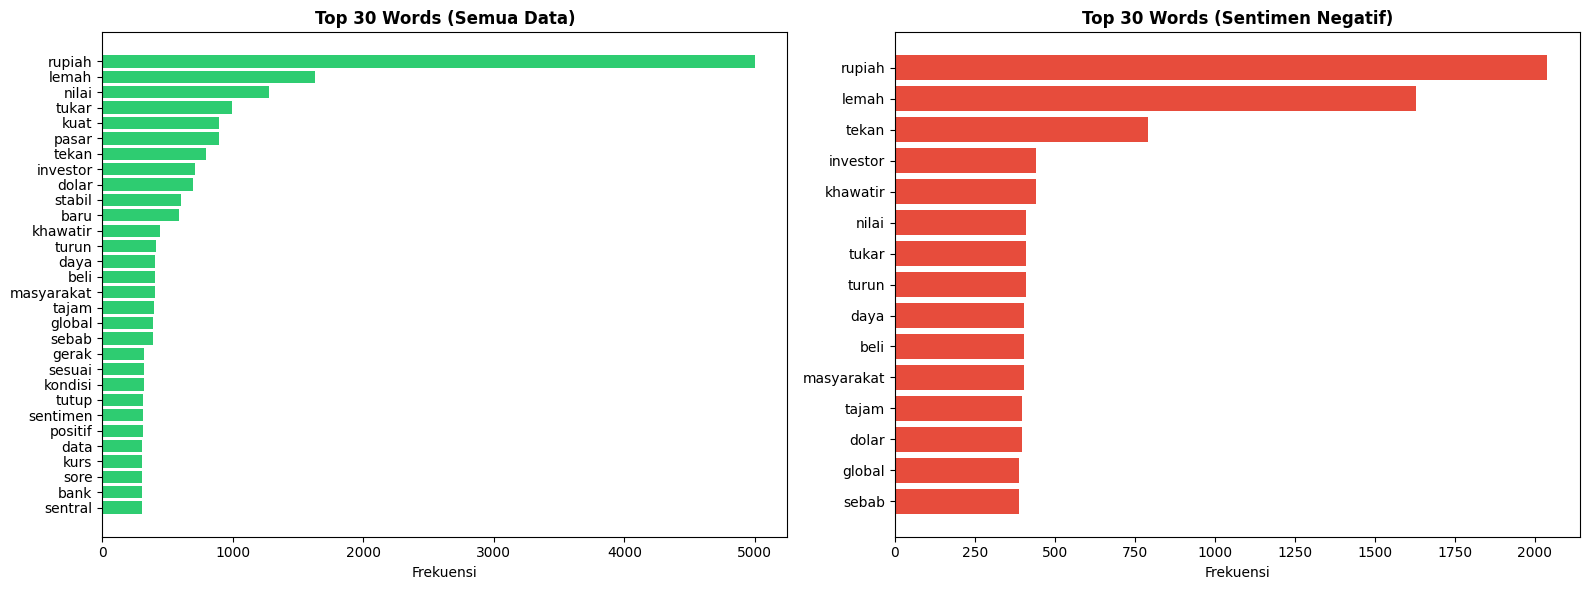

✓ Visualisasi word frequency tersimpan


In [ ]:
from collections import Counter

def get_top_words(texts, n=30):
    """
    Dapatkan top n words dari texts
    """
    all_words = []
    for text in texts:
        all_words.extend(text.split())
    return Counter(all_words).most_common(n)

# Top words semua data
top_words_all = get_top_words(df['teks_cleaned'], 30)
print(f"\nTop 30 Words (Semua Data):")
for word, count in top_words_all:
    print(f"  {word}: {count}")

# Top words sentimen negatif
top_words_neg = get_top_words(df_negative['teks_cleaned'], 30)
print(f"\nTop 30 Words (Sentimen Negatif):")
for word, count in top_words_neg:
    print(f"  {word}: {count}")

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

words_all, counts_all = zip(*top_words_all)
axes[0].barh(range(len(words_all)), counts_all, color='#2ecc71')
axes[0].set_yticks(range(len(words_all)))
axes[0].set_yticklabels(words_all)
axes[0].set_xlabel('Frekuensi')
axes[0].set_title('Top 30 Words (Semua Data)', fontsize=12, fontweight='bold')
axes[0].invert_yaxis()

words_neg, counts_neg = zip(*top_words_neg)
axes[1].barh(range(len(words_neg)), counts_neg, color='#e74c3c')
axes[1].set_yticks(range(len(words_neg)))
axes[1].set_yticklabels(words_neg)
axes[1].set_xlabel('Frekuensi')
axes[1].set_title('Top 30 Words (Sentimen Negatif)', fontsize=12, fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('06_word_frequency.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualisasi word frequency tersimpan")

10. WORD CLOUD

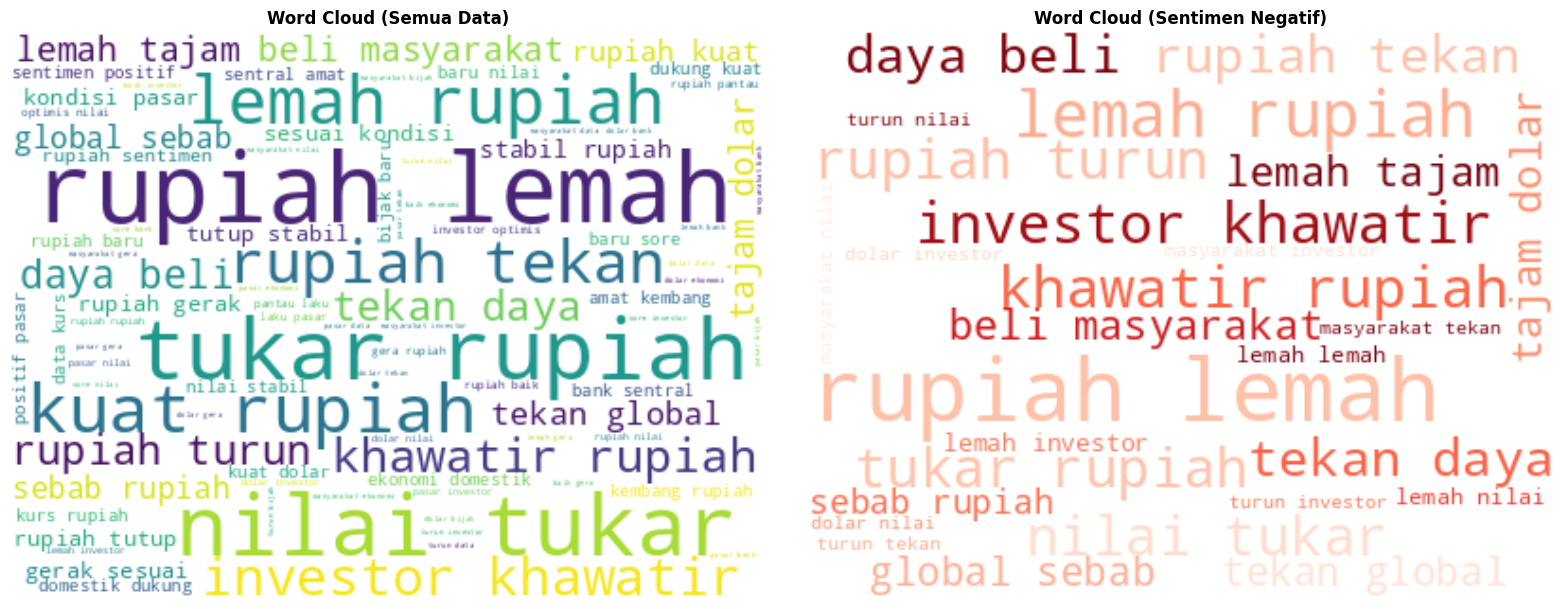

✓ Visualisasi word cloud tersimpan


In [ ]:
# Word Cloud untuk semua data
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

wordcloud_all = WordCloud(
    width=400,
    height=300,
    background_color='white',
    colormap='viridis',
    max_words=100
).generate(' '.join(df['teks_cleaned']))

axes[0].imshow(wordcloud_all, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Word Cloud (Semua Data)', fontsize=12, fontweight='bold')

# Word Cloud untuk sentimen negatif
wordcloud_neg = WordCloud(
    width=400,
    height=300,
    background_color='white',
    colormap='Reds',
    max_words=100
).generate(' '.join(df_negative['teks_cleaned']))

axes[1].imshow(wordcloud_neg, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Word Cloud (Sentimen Negatif)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('07_wordcloud.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualisasi word cloud tersimpan")


TOPIC MODELING - LDA

Preparing corpus for all data...
✓ Dictionary size: 40
✓ Corpus size: 5000

Training LDA models untuk mencari optimal number of topics...
  Training with 2 topics... Coherence: 0.5650
  Training with 3 topics... Coherence: 0.5892
  Training with 4 topics... Coherence: 0.5832
  Training with 5 topics... Coherence: 0.5936
  Training with 6 topics... Coherence: 0.5919
  Training with 7 topics... Coherence: 0.5958
  Training with 8 topics... Coherence: 0.5880
  Training with 9 topics... Coherence: 0.5871
  Training with 10 topics... Coherence: 0.5870

✓ Optimal number of topics: 7


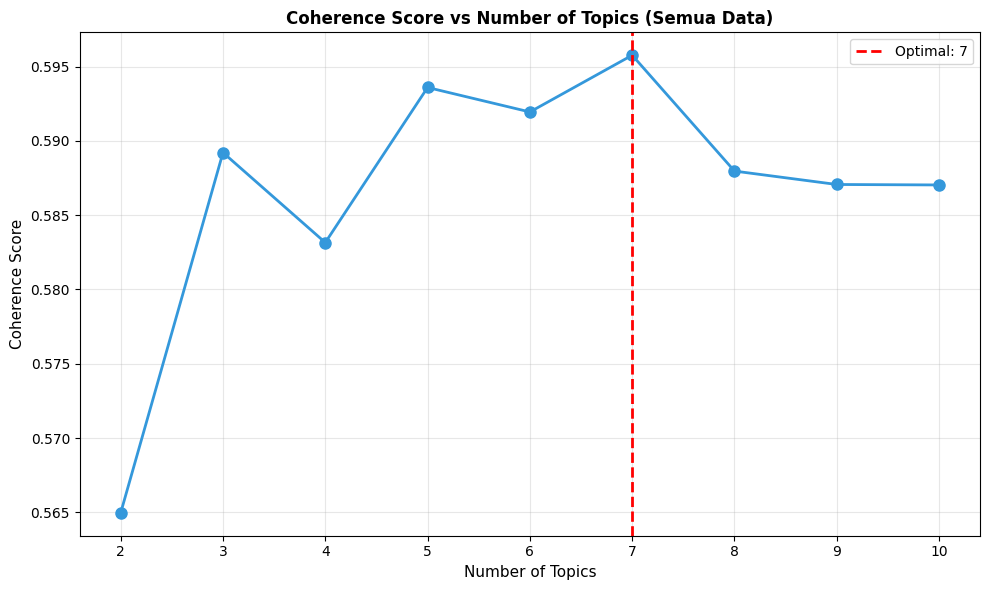

✓ Visualisasi coherence scores tersimpan

Training final LDA model with 7 topics...
✓ Final LDA model trained

Topics dari LDA Model (Semua Data):

Topic 1:
  0.088*"sentral" + 0.088*"kembang" + 0.088*"bank" + 0.088*"amat" + 0.083*"bijak" + 0.083*"baru" + 0.083*"stabil" + 0.083*"nilai" + 0.079*"dukung" + 0.079*"domestik"

Topic 2:
  0.228*"dolar" + 0.139*"turun" + 0.139*"nilai" + 0.139*"tukar" + 0.127*"tajam" + 0.127*"lemah" + 0.101*"kuat" + 0.000*"tekan" + 0.000*"beli" + 0.000*"daya"

Topic 3:
  0.137*"baru" + 0.137*"sore" + 0.137*"kurs" + 0.137*"data" + 0.112*"kuat" + 0.112*"positif" + 0.112*"sentimen" + 0.112*"pasar" + 0.000*"lemah" + 0.000*"investor"

Topic 4:
  0.162*"tekan" + 0.162*"lemah" + 0.086*"daya" + 0.086*"beli" + 0.086*"masyarakat" + 0.076*"sebab" + 0.076*"global" + 0.053*"baik" + 0.053*"optimis" + 0.053*"investor"

Topic 5:
  0.249*"pasar" + 0.129*"kondisi" + 0.129*"gerak" + 0.129*"sesuai" + 0.120*"pantau" + 0.120*"laku" + 0.120*"gera" + 0.000*"dolar" + 0.000*"kuat" + 0.

In [ ]:
# Prepare data untuk Gensim
def prepare_corpus(texts):
    """
    Prepare corpus untuk LDA modeling
    """
    # Tokenization
    texts_tokenized = [text.split() for text in texts]

    # Create dictionary
    dictionary = corpora.Dictionary(texts_tokenized)

    # Filter extremes
    dictionary.filter_extremes(no_below=2, no_above=0.7)

    # Create corpus
    corpus = [dictionary.doc2bow(text) for text in texts_tokenized]

    return texts_tokenized, dictionary, corpus

# All data
print("Preparing corpus for all data...")
texts_tokenized_all, dictionary_all, corpus_all = prepare_corpus(df['teks_cleaned'])

print(f"✓ Dictionary size: {len(dictionary_all)}")
print(f"✓ Corpus size: {len(corpus_all)}")

# Train LDA model dengan berbagai jumlah topics untuk menemukan optimal
print("\nTraining LDA models untuk mencari optimal number of topics...")
coherence_scores = []
lda_models_list = [] # Renamed from 'models' to avoid conflict with gensim.models

for num_topics in range(2, 11):
    print(f"  Training with {num_topics} topics...", end=" ")
    lda_model = gensim_models_module.LdaMulticore( # Used aliased gensim_models_module
        corpus=corpus_all,
        id2word=dictionary_all,
        num_topics=num_topics,
        random_state=42,
        passes=10,
        workers=2,
        per_word_topics=True,
        minimum_probability=0.0
    )

    # Calculate coherence score
    coherence_model = CoherenceModel(
        model=lda_model,
        texts=texts_tokenized_all,
        dictionary=dictionary_all,
        coherence='c_v'
    )
    coherence_score = coherence_model.get_coherence()
    coherence_scores.append(coherence_score)
    lda_models_list.append(lda_model) # Appended to lda_models_list

    print(f"Coherence: {coherence_score:.4f}")

# Find optimal number of topics
optimal_num_topics = coherence_scores.index(max(coherence_scores)) + 2
print(f"\n✓ Optimal number of topics: {optimal_num_topics}")

# Visualisasi coherence scores
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(range(2, 11), coherence_scores, marker='o', linewidth=2, markersize=8, color='#3498db')
ax.axvline(x=optimal_num_topics, color='red', linestyle='--', linewidth=2, label=f'Optimal: {optimal_num_topics}')
ax.set_xlabel('Number of Topics', fontsize=11)
ax.set_ylabel('Coherence Score', fontsize=11)
ax.set_title('Coherence Score vs Number of Topics (Semua Data)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig('08_coherence_scores_all.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualisasi coherence scores tersimpan")

# Train final LDA model
print(f"\nTraining final LDA model with {optimal_num_topics} topics...")
lda_model_final = gensim_models_module.LdaMulticore( # Used aliased gensim_models_module
    corpus=corpus_all,
    id2word=dictionary_all,
    num_topics=optimal_num_topics,
    random_state=42,
    passes=15,
    workers=2,
    per_word_topics=True,
    minimum_probability=0.0
)

print("✓ Final LDA model trained")

# Display topics
print(f"\nTopics dari LDA Model (Semua Data):")
for idx, topic in lda_model_final.print_topics(-1):
    print(f"\nTopic {idx + 1}:")
    print(f"  {topic}")

12. TOPIC MODELING - LDA untuk SENTIMEN NEGATIF

Preparing corpus for negative sentiment data...
✓ Dictionary size: 13
✓ Corpus size: 2039

Training LDA models untuk mencari optimal number of topics (Negatif)...
  Training with 2 topics... Coherence: 0.5255
  Training with 3 topics... Coherence: 0.5255
  Training with 4 topics... Coherence: 0.5255
  Training with 5 topics... Coherence: 0.5255
  Training with 6 topics... Coherence: 0.5255
  Training with 7 topics... Coherence: 0.5255
  Training with 8 topics... Coherence: 0.5255

✓ Optimal number of topics (Negatif): 3


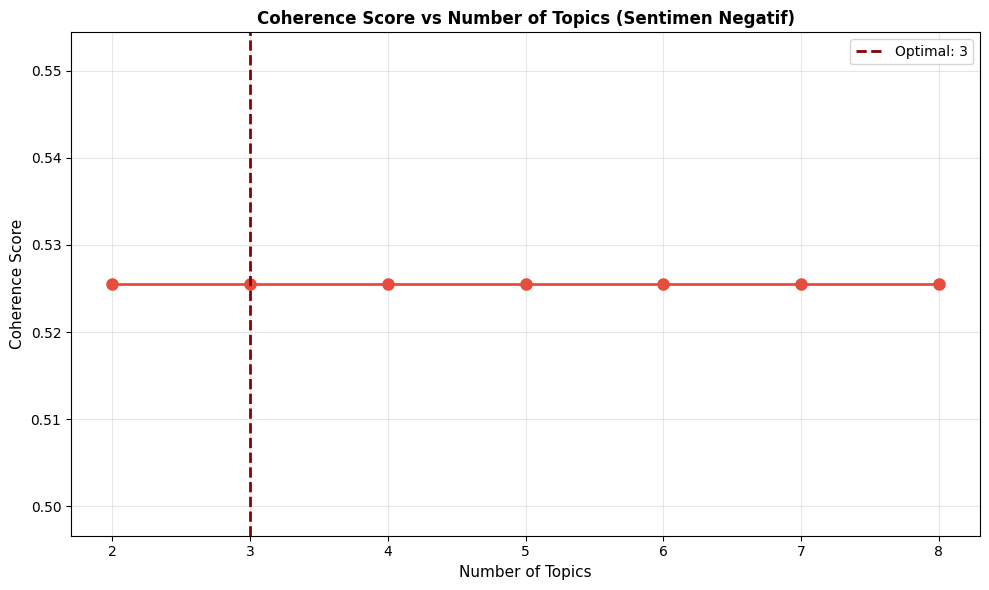

✓ Visualisasi coherence scores negatif tersimpan

Training final LDA model with 3 topics (Negatif)...
✓ Final LDA model (Negatif) trained


In [ ]:
# Negative data
print("Preparing corpus for negative sentiment data...")
texts_tokenized_neg, dictionary_neg, corpus_neg = prepare_corpus(df_negative['teks_cleaned'])

print(f"✓ Dictionary size: {len(dictionary_neg)}")
print(f"✓ Corpus size: {len(corpus_neg)}")

# Train LDA model untuk negatif
print("\nTraining LDA models untuk mencari optimal number of topics (Negatif)...")
coherence_scores_neg = []
lda_models_list_neg = [] # Renamed from 'models_neg' to avoid conflict

for num_topics in range(2, 9):
    print(f"  Training with {num_topics} topics...", end=" ")
    lda_model_neg_temp = gensim_models_module.LdaMulticore( # Used aliased gensim_models_module
        corpus=corpus_neg,
        id2word=dictionary_neg,
        num_topics=num_topics,
        random_state=42,
        passes=10,
        workers=2,
        per_word_topics=True,
        minimum_probability=0.0
    )

    # Calculate coherence score
    coherence_model_neg = CoherenceModel(
        model=lda_model_neg_temp,
        texts=texts_tokenized_neg,
        dictionary=dictionary_neg,
        coherence='c_v'
    )
    coherence_score_neg = coherence_model_neg.get_coherence()
    coherence_scores_neg.append(coherence_score_neg)
    lda_models_list_neg.append(lda_model_neg_temp) # Appended to lda_models_list_neg

    print(f"Coherence: {coherence_score_neg:.4f}")

# Find optimal for negative
optimal_num_topics_neg = coherence_scores_neg.index(max(coherence_scores_neg)) + 2
print(f"\n✓ Optimal number of topics (Negatif): {optimal_num_topics_neg}")

# Visualisasi coherence scores negatif
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(range(2, 9), coherence_scores_neg, marker='o', linewidth=2, markersize=8, color='#e74c3c')
ax.axvline(x=optimal_num_topics_neg, color='darkred', linestyle='--', linewidth=2, label=f'Optimal: {optimal_num_topics_neg}')
ax.set_xlabel('Number of Topics', fontsize=11)
ax.set_ylabel('Coherence Score', fontsize=11)
ax.set_title('Coherence Score vs Number of Topics (Sentimen Negatif)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig('09_coherence_scores_negative.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualisasi coherence scores negatif tersimpan")

# Train final LDA model untuk negatif
print(f"\nTraining final LDA model with {optimal_num_topics_neg} topics (Negatif)...")
lda_model_negative_final = gensim_models_module.LdaMulticore( # Used aliased gensim_models_module
    corpus=corpus_neg,
    id2word=dictionary_neg,
    num_topics=optimal_num_topics_neg,
    random_state=42,
    passes=15,
    workers=2,
    per_word_topics=True,
    minimum_probability=0.0
)

print("✓ Final LDA model (Negatif) trained")

In [ ]:
# Display topics untuk negatif
print(f"\n{'='*80}")
print(f"TOPICS DARI LDA MODEL (SENTIMEN NEGATIF) - FAKTOR DOMINAN")
print(f"{'='*80}")

topics_negative = []
for idx, topic in lda_model_negative_final.print_topics(-1):
    print(f"\nTopic {idx + 1}:")
    print(f"  {topic}")
    topics_negative.append({
        'topic_id': idx + 1,
        'topic_terms': topic
    })


TOPICS DARI LDA MODEL (SENTIMEN NEGATIF) - FAKTOR DOMINAN

Topic 1:
  0.494*"dolar" + 0.494*"tajam" + 0.002*"tekan" + 0.001*"nilai" + 0.001*"tukar" + 0.001*"turun" + 0.001*"masyarakat" + 0.001*"daya" + 0.001*"beli" + 0.001*"global"

Topic 2:
  0.144*"turun" + 0.144*"nilai" + 0.144*"tukar" + 0.142*"beli" + 0.142*"daya" + 0.142*"masyarakat" + 0.141*"tekan" + 0.000*"tajam" + 0.000*"dolar" + 0.000*"global"

Topic 3:
  0.215*"khawatir" + 0.215*"investor" + 0.190*"tekan" + 0.189*"sebab" + 0.189*"global" + 0.000*"tajam" + 0.000*"dolar" + 0.000*"turun" + 0.000*"tukar" + 0.000*"nilai"


13. TOPIC-SENTIMENT MAPPING

Extracting document-topic distributions...

Topic Distribution dalam Sentimen Negatif:

Topic      Frequency       Avg Weight      Percentage     
-------------------------------------------------------
Topic 0  2039            0.2216          100.00         %
Topic 1  2039            0.4007          100.00         %
Topic 2  2039            0.3777          100.00         %


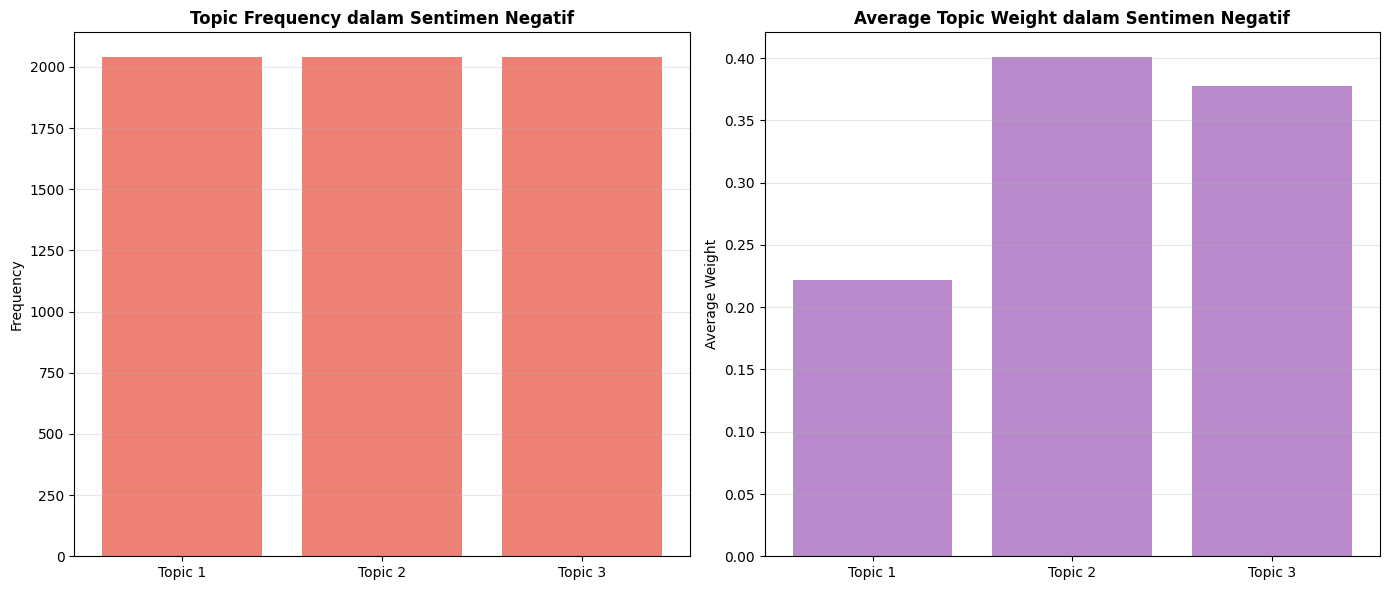

✓ Visualisasi topic distribution tersimpan


In [ ]:
# Get topic distribution untuk setiap dokumen (sentimen negatif)
def get_document_topics(corpus, lda_model):
    """
    Get topic distribution untuk setiap dokumen
    """
    doc_topics = []
    for doc_id, doc in enumerate(corpus):
        topics = lda_model.get_document_topics(doc)
        doc_topics.append({
            'doc_id': doc_id,
            'topics': topics
        })
    return doc_topics

print("Extracting document-topic distributions...")
doc_topics_neg = get_document_topics(corpus_neg, lda_model_negative_final)

# Calculate topic frequency
topic_counts = {}
topic_weights = {}

for doc in doc_topics_neg:
    for topic_id, weight in doc['topics']:
        if topic_id not in topic_counts:
            topic_counts[topic_id] = 0
            topic_weights[topic_id] = 0
        topic_counts[topic_id] += 1
        topic_weights[topic_id] += weight

# Normalize weights
topic_avg_weights = {topic_id: topic_weights[topic_id] / topic_counts[topic_id]
                     for topic_id in topic_counts}

print(f"\nTopic Distribution dalam Sentimen Negatif:")
print(f"\n{'Topic':<10} {'Frequency':<15} {'Avg Weight':<15} {'Percentage':<15}")
print(f"{'-'*55}")

sorted_topics = sorted(topic_counts.items(), key=lambda x: x[1], reverse=True)
for topic_id, count in sorted_topics:
    percentage = (count / len(corpus_neg)) * 100
    avg_weight = topic_avg_weights[topic_id]
    print(f"Topic {topic_id:<2} {count:<15} {avg_weight:<15.4f} {percentage:<15.2f}%")

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

topic_ids = list(sorted(topic_counts.keys()))
frequencies = [topic_counts[t] for t in topic_ids]
avg_weights = [topic_avg_weights[t] for t in topic_ids]

axes[0].bar([f'Topic {i+1}' for i in topic_ids], frequencies, color='#e74c3c', alpha=0.7)
axes[0].set_ylabel('Frequency')
axes[0].set_title('Topic Frequency dalam Sentimen Negatif', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].bar([f'Topic {i+1}' for i in topic_ids], avg_weights, color='#9b59b6', alpha=0.7)
axes[1].set_ylabel('Average Weight')
axes[1].set_title('Average Topic Weight dalam Sentimen Negatif', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('10_topic_distribution_negative.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualisasi topic distribution tersimpan")

14. ADVANCED TOPIC VISUALIZATION

Creating interactive LDA visualization...
⚠ Warning: Could not create interactive visualization: name 'pyLDAvis' is not defined

Creating topic-term matrix...


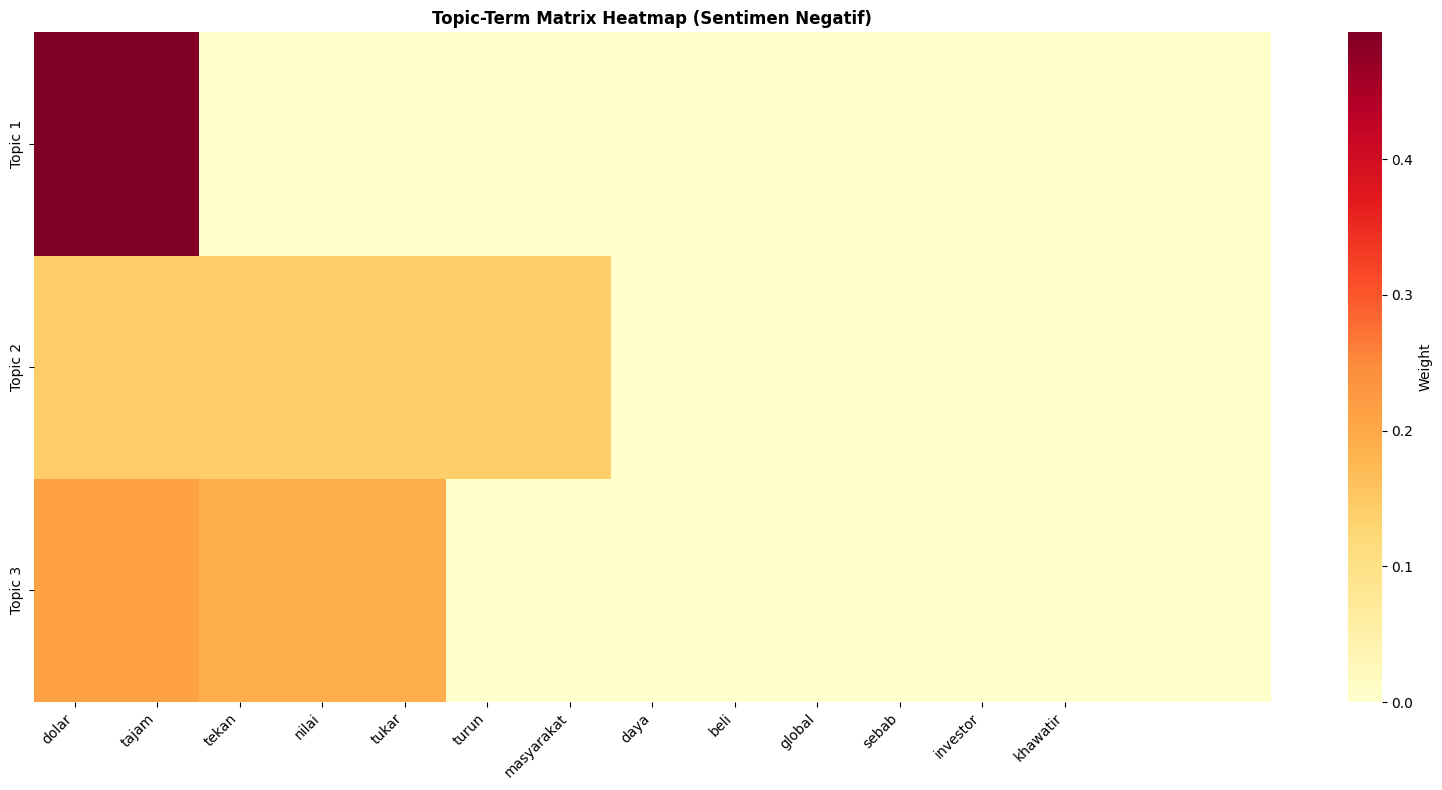

✓ Topic-term heatmap tersimpan


In [ ]:
# Visualisasi interaktif LDA untuk sentimen negatif
print("Creating interactive LDA visualization...")

try:
    vis_neg = gensimvis.prepare(
        lda_model_negative_final,
        corpus_neg,
        dictionary_neg,
        # mds_dist=0.5, # Removed as it causes a warning in some pyLDAvis versions
        sort_topics=False
    )

    # Save visualization
    pyLDAvis.save_html(vis_neg, '11_lda_visualization_negative.html')
    print("✓ Interactive LDA visualization for negative sentiment saved")

except Exception as e:
    print(f"⚠ Warning: Could not create interactive visualization: {e}")

# Topic-Term Matrix
print("\nCreating topic-term matrix...")

topic_term_matrix = np.zeros((optimal_num_topics_neg, len(dictionary_neg)))

for topic_id in range(optimal_num_topics_neg):
    # show_topic returns a list of (word_string, weight) tuples
    terms_with_weights = lda_model_negative_final.show_topic(topic_id, topn=len(dictionary_neg))
    for word_string, weight in terms_with_weights:
        # Get the integer ID for the word string from the dictionary
        if word_string in dictionary_neg.token2id: # Check if word exists in dictionary
            actual_term_id = dictionary_neg.token2id[word_string]
            topic_term_matrix[topic_id, actual_term_id] = weight

# Heatmap
fig, ax = plt.subplots(figsize=(16, 8))

# Get top terms untuk setiap topic
top_terms_per_topic = []
for topic_id in range(optimal_num_topics_neg):
    terms = lda_model_negative_final.show_topic(topic_id, topn=15)
    top_terms_per_topic.append(terms)

# Create heatmap data
heatmap_data = np.zeros((optimal_num_topics_neg, 15))
term_labels = []

for topic_idx, terms in enumerate(top_terms_per_topic):
    current_topic_terms_labels = []
    for term_idx, (word_string, weight) in enumerate(terms):
        heatmap_data[topic_idx, term_idx] = weight
        current_topic_terms_labels.append(word_string)
    # For simplicity, use terms from the first topic as x-axis labels
    if topic_idx == 0:
        term_labels = current_topic_terms_labels

sns.heatmap(
    heatmap_data,
    xticklabels=term_labels,
    yticklabels=[f'Topic {i+1}' for i in range(optimal_num_topics_neg)],
    cmap='YlOrRd',
    ax=ax,
    cbar_kws={'label': 'Weight'}
)
ax.set_title('Topic-Term Matrix Heatmap (Sentimen Negatif)', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('12_topic_term_heatmap_negative.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Topic-term heatmap tersimpan")

15. INTERPRETATION & LABELING

In [ ]:
# Manual labeling berdasarkan top terms
topic_labels = {
    0: "Faktor Teknis/Global",
    1: "Dampak Ekonomi Domestik",
    2: "Sentimen Investor",
    3: "Kebijakan Pemerintah",
    4: "Data/Analisis Pasar"
}

if optimal_num_topics_neg > 5:
    for i in range(5, optimal_num_topics_neg):
        topic_labels[i] = f"Topic {i+1}"

print("\nTopic Labels (Faktor Dominan Pembentuk Sentimen Negatif):")
print(f"{'-'*80}")

interpretation_results = []

for topic_id in range(optimal_num_topics_neg):
    terms = lda_model_negative_final.show_topic(topic_id, topn=10)
    top_terms = [term for term, weight in terms]
    weights = [weight for term, weight in terms]

    frequency = topic_counts.get(topic_id, 0)
    percentage = (frequency / len(corpus_neg)) * 100
    avg_weight = topic_avg_weights.get(topic_id, 0)

    label = topic_labels.get(topic_id, f"Topic {topic_id+1}")

    print(f"\n{label.upper()}")
    print(f"{'='*80}")
    print(f"Topic ID: {topic_id}")
    print(f"Frequency: {frequency} ({percentage:.2f}%)")
    print(f"Average Weight: {avg_weight:.4f}")
    print(f"Top Terms: {', '.join(top_terms)}")

    interpretation_results.append({
        'topic_id': topic_id,
        'label': label,
        'frequency': frequency,
        'percentage': percentage,
        'avg_weight': avg_weight,
        'top_terms': top_terms,
        'top_terms_with_weights': terms
    })



Topic Labels (Faktor Dominan Pembentuk Sentimen Negatif):
--------------------------------------------------------------------------------

FAKTOR TEKNIS/GLOBAL
Topic ID: 0
Frequency: 2039 (100.00%)
Average Weight: 0.2216
Top Terms: dolar, tajam, tekan, nilai, tukar, turun, masyarakat, daya, beli, global

DAMPAK EKONOMI DOMESTIK
Topic ID: 1
Frequency: 2039 (100.00%)
Average Weight: 0.4007
Top Terms: turun, nilai, tukar, beli, daya, masyarakat, tekan, tajam, dolar, global

SENTIMEN INVESTOR
Topic ID: 2
Frequency: 2039 (100.00%)
Average Weight: 0.3777
Top Terms: khawatir, investor, tekan, sebab, global, tajam, dolar, turun, tukar, nilai


16. SUMMARY & KEY FINDINGS

In [ ]:
# Sort by frequency
sorted_findings = sorted(interpretation_results, key=lambda x: x['frequency'], reverse=True)

print("\n🎯 FAKTOR DOMINAN PEMBENTUK SENTIMEN NEGATIF (Peringkat):")
print(f"{'-'*80}\n")

for rank, finding in enumerate(sorted_findings, 1):
    print(f"{rank}. {finding['label'].upper()}")
    print(f"   Dominansi: {finding['percentage']:.2f}%")
    print(f"   Jumlah Dokumen: {finding['frequency']}")
    print(f"   Bobot Rata-rata: {finding['avg_weight']:.4f}")
    print(f"   Kata Kunci: {', '.join(finding['top_terms'][:5])}")
    print()


🎯 FAKTOR DOMINAN PEMBENTUK SENTIMEN NEGATIF (Peringkat):
--------------------------------------------------------------------------------

1. FAKTOR TEKNIS/GLOBAL
   Dominansi: 100.00%
   Jumlah Dokumen: 2039
   Bobot Rata-rata: 0.2216
   Kata Kunci: dolar, tajam, tekan, nilai, tukar

2. DAMPAK EKONOMI DOMESTIK
   Dominansi: 100.00%
   Jumlah Dokumen: 2039
   Bobot Rata-rata: 0.4007
   Kata Kunci: turun, nilai, tukar, beli, daya

3. SENTIMEN INVESTOR
   Dominansi: 100.00%
   Jumlah Dokumen: 2039
   Bobot Rata-rata: 0.3777
   Kata Kunci: khawatir, investor, tekan, sebab, global



17. VISUALIZATION SUMMARY

### Visualisasi Ringkasan Menggunakan Matplotlib

Untuk menghindari masalah dengan `kaleido` dan `plotly`, kita akan membuat visualisasi ringkasan faktor dominan ini menggunakan Matplotlib.

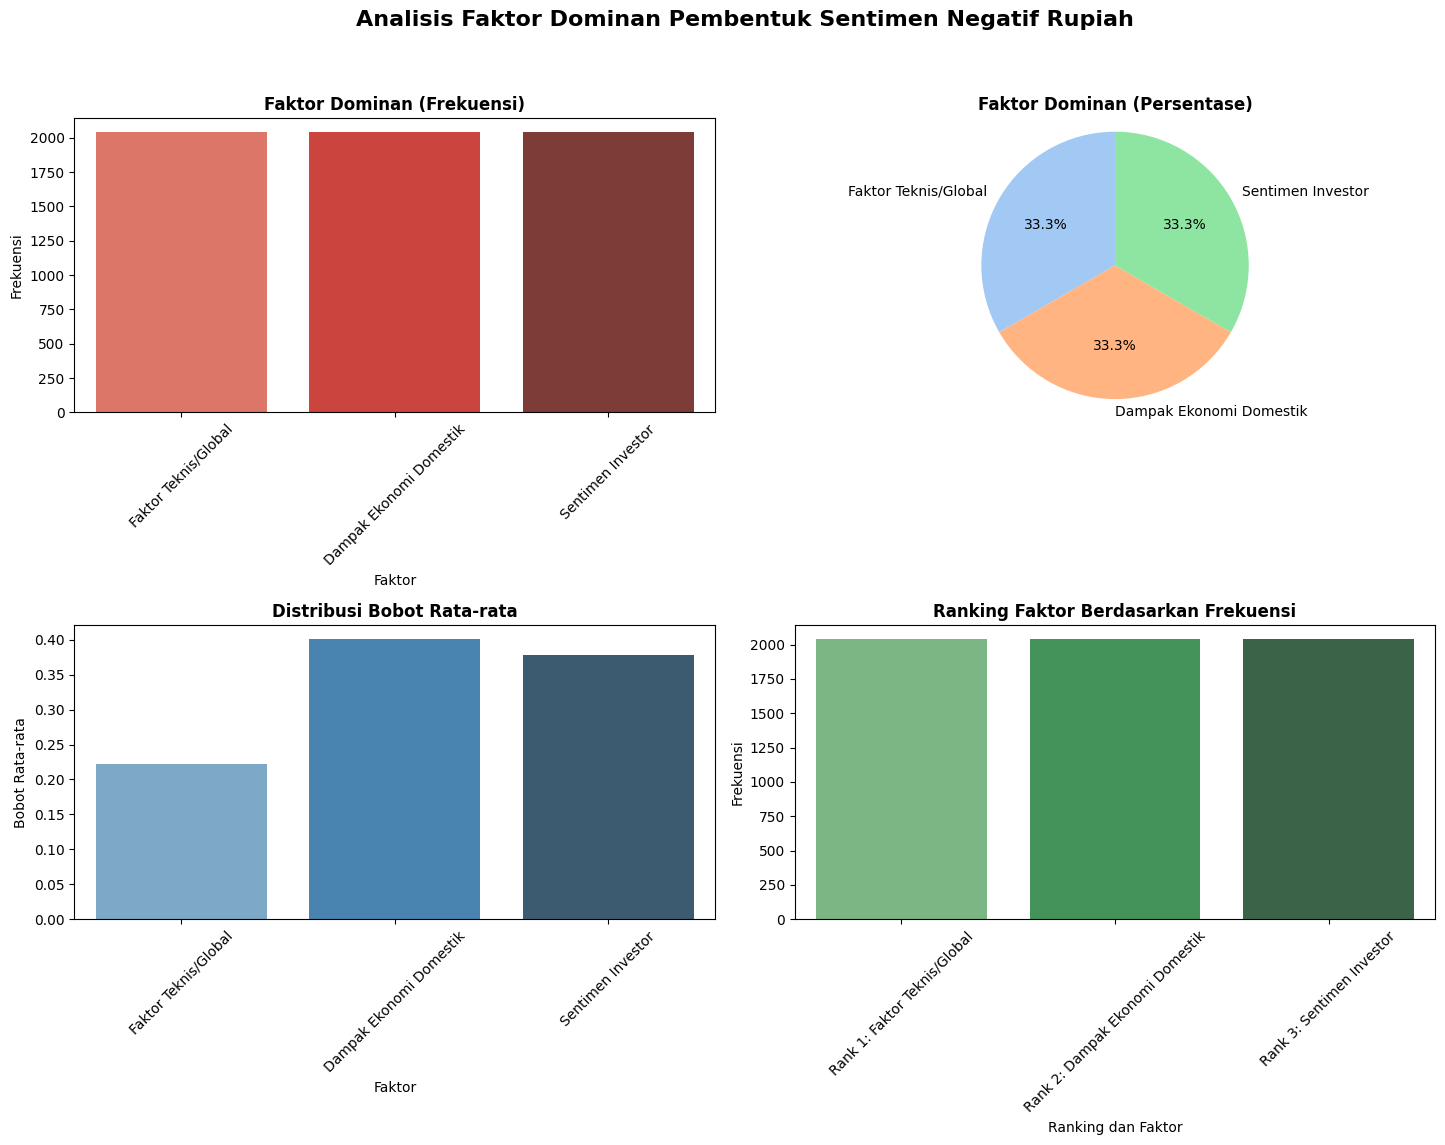

✓ Summary analysis visualization tersimpan (menggunakan Matplotlib)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract data from sorted_findings
labels = [r['label'] for r in sorted_findings]
frequencies = [r['frequency'] for r in sorted_findings]
percentages = [r['percentage'] for r in sorted_findings]
avg_weights = [r['avg_weight'] for r in sorted_findings]

# Create a figure with a 2x2 subplot layout
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Analisis Faktor Dominan Pembentuk Sentimen Negatif Rupiah', fontsize=16, fontweight='bold')

# Subplot 1: Frequency Bar Plot
sns.barplot(x=labels, y=frequencies, ax=axes[0, 0], palette='Reds_d')
axes[0, 0].set_title('Faktor Dominan (Frekuensi)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Faktor')
axes[0, 0].set_ylabel('Frekuensi')
axes[0, 0].tick_params(axis='x', rotation=45)

# Subplot 2: Percentage Pie Chart
# For pie chart, it's better to filter out categories with 0 percentage if any
# In this case, all are 100%, but for robustness:
pie_labels = [label for i, label in enumerate(labels) if percentages[i] > 0]
pie_percentages = [p for p in percentages if p > 0]

axes[0, 1].pie(pie_percentages, labels=pie_labels, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel')[0:len(pie_labels)])
axes[0, 1].set_title('Faktor Dominan (Persentase)', fontsize=12, fontweight='bold')
axes[0, 1].axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.

# Subplot 3: Average Weights Bar Plot
sns.barplot(x=labels, y=avg_weights, ax=axes[1, 0], palette='Blues_d')
axes[1, 0].set_title('Distribusi Bobot Rata-rata', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Faktor')
axes[1, 0].set_ylabel('Bobot Rata-rata')
axes[1, 0].tick_params(axis='x', rotation=45)

# Subplot 4: Ranking Bar Plot (using frequencies, but ordered by rank)
# Assuming sorted_findings is already sorted by frequency in descending order for ranking
ranking_labels = [f"Rank {i+1}: {l}" for i, l in enumerate(labels)]
sns.barplot(x=ranking_labels, y=frequencies, ax=axes[1, 1], palette='Greens_d')
axes[1, 1].set_title('Ranking Faktor Berdasarkan Frekuensi', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Ranking dan Faktor')
axes[1, 1].set_ylabel('Frekuensi')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.savefig('13_summary_analysis_matplotlib.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Summary analysis visualization tersimpan (menggunakan Matplotlib)")

In [ ]:
df_summary = pd.DataFrame(interpretation_results)
display(df_summary.head())

,topic_id,label,frequency,percentage,avg_weight,top_terms,top_terms_with_weights
0,0,Faktor Teknis/Global,2039,100.0,0.221604,"[dolar, tajam, tekan, nilai, tukar, turun, mas...","[(dolar, 0.49353924), (tajam, 0.49353474), (te..."
1,1,Dampak Ekonomi Domestik,2039,100.0,0.400650,"[turun, nilai, tukar, beli, daya, masyarakat, ...","[(turun, 0.14365396), (nilai, 0.14365144), (tu..."
2,2,Sentimen Investor,2039,100.0,0.377736,"[khawatir, investor, tekan, sebab, global, taj...","[(khawatir, 0.21516894), (investor, 0.21516444..."


18. EXPORT RESULTS

In [ ]:
# Save interpretation results to CSV
results_df = pd.DataFrame(interpretation_results)
results_df = results_df.sort_values('frequency', ascending=False)
results_df.to_csv('topic_interpretation_results.csv', index=False)
print("✓ Interpretation results exported to CSV")

# Save detailed report
with open('research_report.txt', 'w', encoding='utf-8') as f:
    f.write("="*80 + "\n")
    f.write("LAPORAN PENELITIAN\n")
    f.write("Identifikasi Faktor Dominan Pembentuk Sentimen Negatif Masyarakat\n")
    f.write("terhadap Pelemahan Rupiah Menggunakan NLP dan Topic Modeling\n")
    f.write("="*80 + "\n\n")

    f.write("1. DATASET SUMMARY\n")
    f.write("-"*80 + "\n")
    f.write(f"Total Data: {len(df)}\n")
    f.write(f"Sentimen Negatif: {len(df_negative)} ({len(df_negative)/len(df)*100:.2f}%)\n")
    f.write(f"Sentimen Positif: {len(df[df['sentimen']=='positif'])} ({len(df[df['sentimen']=='positif'])/len(df)*100:.2f}%)\n")
    f.write(f"Sentimen Netral: {len(df[df['sentimen']=='netral'])} ({len(df[df['sentimen']=='netral'])/len(df)*100:.2f}%)\n\n")

    f.write("2. TOPIC MODELING RESULTS\n")
    f.write("-"*80 + "\n")
    f.write(f"Optimal Number of Topics: {optimal_num_topics_neg}\n")
    f.write(f"Coherence Score: {max(coherence_scores_neg):.4f}\n\n")

    f.write("3. FAKTOR DOMINAN PEMBENTUK SENTIMEN NEGATIF\n")
    f.write("-"*80 + "\n\n")

    for rank, finding in enumerate(sorted_findings, 1):
        f.write(f"{rank}. {finding['label'].upper()}\n")
        f.write(f"   Dominansi: {finding['percentage']:.2f}%\n")
        f.write(f"   Jumlah Dokumen: {finding['frequency']}\n")
        f.write(f"   Bobot Rata-rata: {finding['avg_weight']:.4f}\n")
        f.write(f"   Top Terms:\n")
        for term, weight in finding['top_terms_with_weights'][:10]:
            f.write(f"     - {term}: {weight:.4f}\n")
        f.write("\n")

    f.write("\n4. CONCLUSIONS\n")
    f.write("-"*80 + "\n")
    f.write(f"Faktor paling dominan: {sorted_findings[0]['label']}\n")
    f.write(f"Dominansi: {sorted_findings[0]['percentage']:.2f}%\n")

print("✓ Detailed report exported to TXT")

# Save processed data
df.to_csv('processed_data_with_topics.csv', index=False)
print("✓ Processed data exported to CSV")

# Save negative sentiment analysis
df_negative.to_csv('negative_sentiment_data.csv', index=False)
print("✓ Negative sentiment data exported to CSV")


✓ Interpretation results exported to CSV
✓ Detailed report exported to TXT
✓ Processed data exported to CSV
✓ Negative sentiment data exported to CSV


19. FINAL SUMMARY STATISTICS

In [ ]:
summary_stats = {
    'Total Documents': len(df),
    'Negative Sentiment Documents': len(df_negative),
    'Negative Sentiment %': f"{len(df_negative)/len(df)*100:.2f}%",
    'Optimal Topics': optimal_num_topics_neg,
    'Coherence Score': f"{max(coherence_scores_neg):.4f}",
    'Dictionary Size (Negative)': len(dictionary_neg),
    'Corpus Size (Negative)': len(corpus_neg),
    'Dominant Factor': sorted_findings[0]['label'],
    'Dominant Factor %': f"{sorted_findings[0]['percentage']:.2f}%"
}

for key, value in summary_stats.items():
    print(f"{key:<35}: {value}")

print("\n" + "="*80)
print("✓ PENELITIAN SELESAI")
print("="*80)
print("\n📊 File Output:")
print("  1. 01_distribusi_sentimen.png")
print("  2. 02_statistik_teks.png")
print("  3. 03_temporal_analysis.png")
print("  4. 04_sentiment_analysis.png")
print("  5. 05_tfidf_analysis.png")
print("  6. 06_word_frequency.png")
print("  7. 07_wordcloud.png")
print("  8. 08_coherence_scores_all.png")
print("  9. 09_coherence_scores_negative.png")
print(" 10. 10_topic_distribution_negative.png")
print(" 11. 11_lda_visualization_negative.html")
print(" 12. 12_topic_term_heatmap_negative.png")
print(" 13. 13_summary_analysis.png/.html")
print(" 14. topic_interpretation_results.csv")
print(" 15. research_report.txt")
print(" 16. processed_data_with_topics.csv")
print(" 17. negative_sentiment_data.csv")

print("\n✅ Semua output telah tersimpan dalam folder kerja Anda")

Total Documents                    : 5000
Negative Sentiment Documents       : 2039
Negative Sentiment %               : 40.78%
Optimal Topics                     : 3
Coherence Score                    : 0.5255
Dictionary Size (Negative)         : 13
Corpus Size (Negative)             : 2039
Dominant Factor                    : Faktor Teknis/Global
Dominant Factor %                  : 100.00%

✓ PENELITIAN SELESAI

📊 File Output:
  1. 01_distribusi_sentimen.png
  2. 02_statistik_teks.png
  3. 03_temporal_analysis.png
  4. 04_sentiment_analysis.png
  5. 05_tfidf_analysis.png
  6. 06_word_frequency.png
  7. 07_wordcloud.png
  8. 08_coherence_scores_all.png
  9. 09_coherence_scores_negative.png
 10. 10_topic_distribution_negative.png
 11. 11_lda_visualization_negative.html
 12. 12_topic_term_heatmap_negative.png
 13. 13_summary_analysis.png/.html
 14. topic_interpretation_results.csv
 15. research_report.txt
 16. processed_data_with_topics.csv
 17. negative_sentiment_data.csv

✅ Semua out